In [ ]:
## main code


loading data...
NAPS rows: 2755
Compact raw rows: 36347
Compact 15-min rows: 2783
Merged rows: 2755

Q1. PM2.5 humidity correction

Raw model (PM only)
  RMSE: 88.681
  MAE: 34.755
  R2: -0.055
  N: 817

Corrected model (PM + RH + Temp)
  RMSE: 85.732
  MAE: 24.508
  R2: 0.014
  N: 817

RH > 75% | Raw model
  RMSE: 34.472
  MAE: 32.647
  R2: -3.968
  N: 192

RH > 75% | Corrected model
  RMSE: 15.634
  MAE: 12.509
  R2: -0.022
  N: 192

RH > 85% | Raw model
  RMSE: 36.904
  MAE: 35.350
  R2: -9.340
  N: 88

RH > 85% | Corrected model
  RMSE: 12.264
  MAE: 10.339
  R2: -0.142
  N: 88

PM bias by RH band:
RH_band  count      mean    median       std
   <60%   1765 -5.410925 -5.430714 75.737275
 60-75%    706 30.611509 15.515187 57.451004
 75-85%    161 41.192582  4.192923 90.275119
85-100%     88 18.648284 22.038533 14.771931


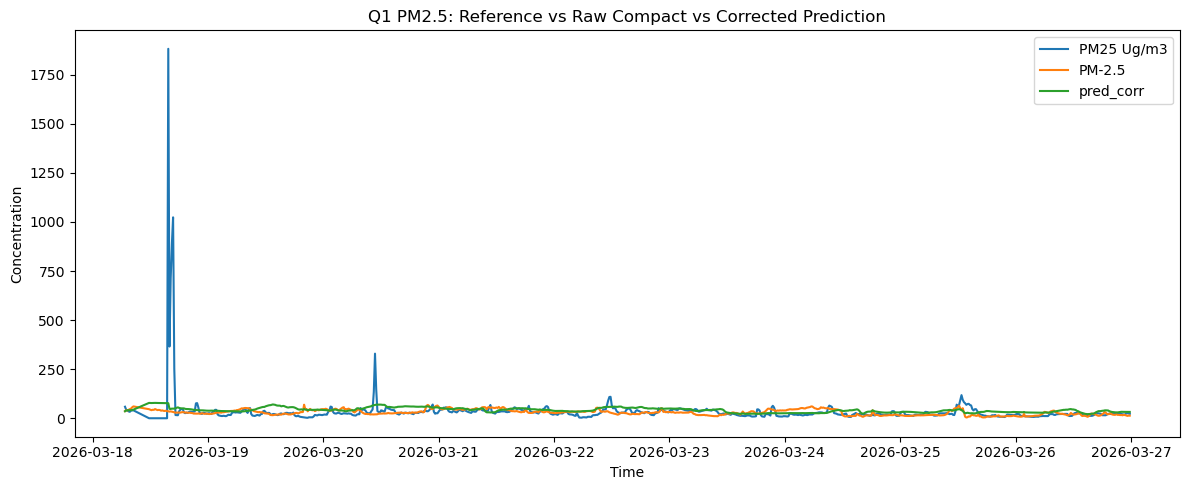

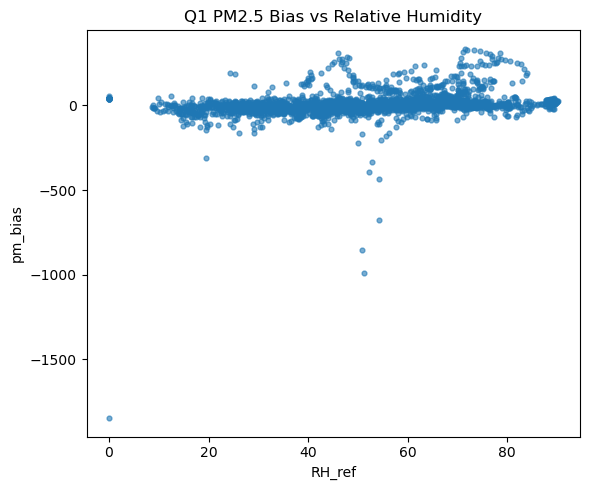


Q2. NO2 temporal harmonization and lag

Baseline comparison
  correlation: 0.096
  RMSE: 48.035
  MAE: 35.650
  N: 2720

Best alignment (window=60 min, lag=16 min)
  correlation: 0.181
  RMSE: 41.646
  MAE: 32.141
  N: 2724


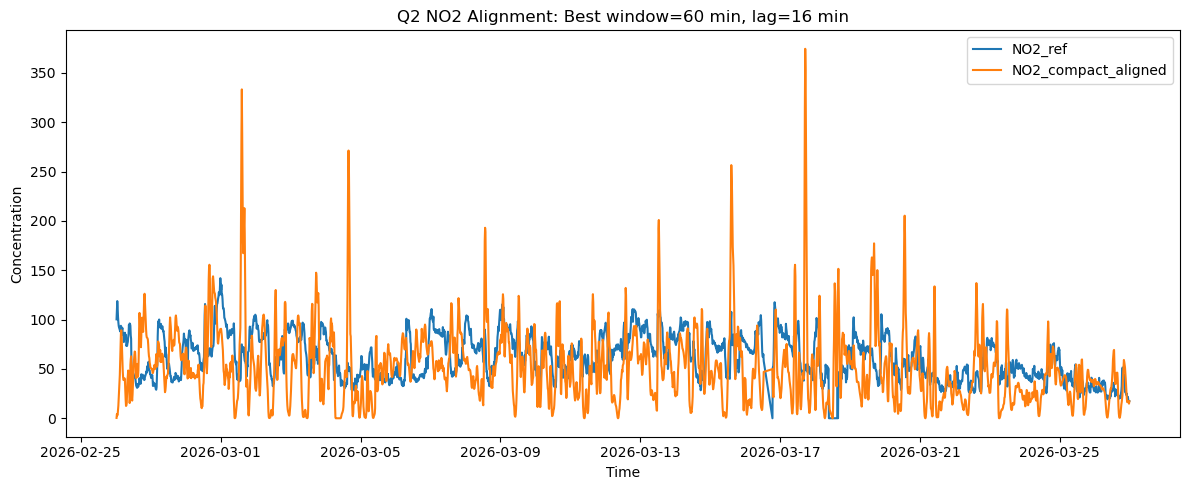


Q3. NO2-O3 cross-sensitivity fusion

Model 1: raw NO2 only
  RMSE: 28.370
  MAE: 24.619
  R2: -1.465
  N: 817

Model 2: raw NO2 + O3 + met
  RMSE: 29.590
  MAE: 20.323
  R2: -1.681
  N: 817

Model 3: dynamic O3 + afternoon + met
  RMSE: 23.725
  MAE: 17.172
  R2: -0.724
  N: 817

Afternoon only | Model 1
  RMSE: 34.553
  MAE: 30.326
  R2: -3.120
  N: 216

Afternoon only | Model 2
  RMSE: 46.540
  MAE: 29.723
  R2: -6.474
  N: 216

Afternoon only | Model 3
  RMSE: 32.104
  MAE: 18.798
  R2: -2.557
  N: 216

Cross-sensitivity diagnostics:
  compact_NO2_vs_compact_O3_alltime: 0.365
  reference_NO2_vs_reference_O3_alltime: -0.472
  compact_NO2_vs_compact_O3_afternoon: 0.374
  reference_NO2_vs_reference_O3_afternoon: 0.064


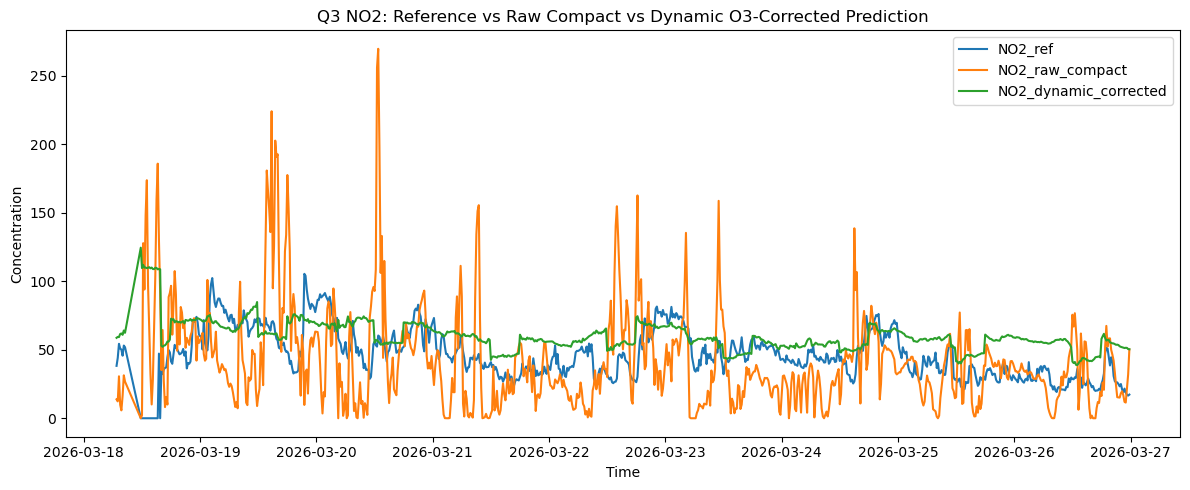

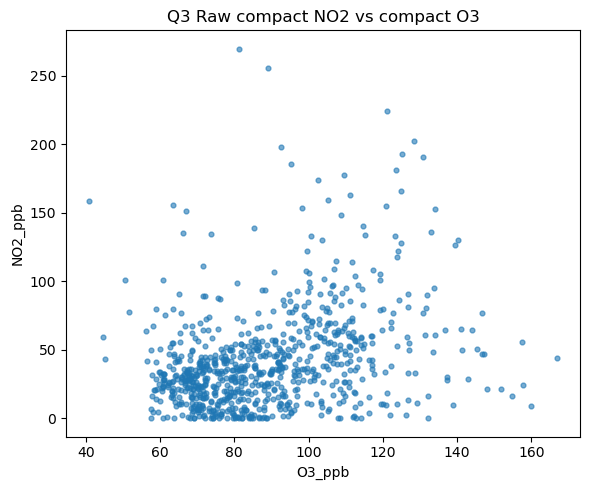

In [6]:
import os
import importlib
import util
importlib.reload(util)
from util import (make_out_folder, load_naps, load_compact, compact_to_15, merge_data, show_metrics, save_line,
    save_scatter, run_q1, q1_rh_bias, run_q2, run_q3,)


def main():
    # input is excel file
    input = r"E:\Comp_exam_UofT\Comp_EXam_Questions_Manisha_1_2026-04-06\NAPS Reference and Compact Station Data Bakhtari.xlsx"

    # out is output folder
    out = r"E:\Comp_exam_UofT\Writting\Manisha comp\Bakhtari\code_out\air_sensor_outputs"

    make_out_folder(out)

    print("\nloading data...")

    
    x = load_naps(input) # naps
    y = load_compact(input, x=6) #compact raw
    x1 = compact_to_15(y) # compact 15 min
    y1 = merge_data(x, x1) # y1 merged data
    y1.to_csv(os.path.join(out, "merged_reference_compact_15min.csv"), index=False)

    print(f"NAPS rows: {len(x)}")
    print(f"Compact raw rows: {len(y)}")
    print(f"Compact 15-min rows: {len(x1)}")
    print(f"Merged rows: {len(y1)}")

    # Q1
    x2 = run_q1(y1, y=True, a=False)
    y2 = q1_rh_bias(y1)

    y2.to_csv(os.path.join(out, "q1_pm25_bias_by_rh_band.csv"), index=False)
    x2.out.to_csv(os.path.join(out, "q1_pm25_test_predictions.csv"), index=False)

    print("\n==============================")
    print("Q1. PM2.5 humidity correction")
    print("==============================")
    show_metrics("Raw model (PM only)", x2.x)
    show_metrics("Corrected model (PM + RH + Temp)", x2.y)

    if x2.a is not None:
        show_metrics("RH > 75% | Raw model", x2.a)
        show_metrics("RH > 75% | Corrected model", x2.b)

    if x2.c is not None:
        show_metrics("RH > 85% | Raw model", x2.c)
        show_metrics("RH > 85% | Corrected model", x2.d)

    print("\nPM bias by RH band:")
    print(y2.to_string(index=False))

    save_line(
        x2.out,
        ["PM25 Ug/m3", "PM-2.5", "pred_corr"],
        out,
        "Q1 PM2.5: Reference vs Raw Compact vs Corrected Prediction",
        "q1_pm25_timeseries.png",
    )

    x3 = y1.dropna(subset=["RH_ref", "PM-2.5", "PM25 Ug/m3"]).copy()
    x3["pm_bias"] = x3["PM-2.5"] - x3["PM25 Ug/m3"]

    save_scatter(
        x3,
        "RH_ref",
        "pm_bias",
        out,
        "Q1 PM2.5 Bias vs Relative Humidity",
        "q1_pm25_bias_vs_rh.png",
    )

    # Q2
    y3 = run_q2(y, x)

    y3.z.to_csv(os.path.join(out, "q2_no2_alignment_grid_search.csv"), index=False)
    y3.out.to_csv(os.path.join(out, "q2_no2_best_aligned_series.csv"), index=False)

    print("\n======================================")
    print("Q2. NO2 temporal harmonization and lag")
    print("======================================")
    show_metrics("Baseline comparison", y3.x)
    show_metrics(f"Best alignment (window={y3.a} min, lag={y3.b} min)", y3.y)

    x4 = y3.out.rename(columns={"NO2 ppb": "NO2_ref", "NO2_smoothed": "NO2_compact_aligned"})

    save_line(
        x4,
        ["NO2_ref", "NO2_compact_aligned"],
        out,
        f"Q2 NO2 Alignment: Best window={y3.a} min, lag={y3.b} min",
        "q2_no2_aligned_timeseries.png",
    )

    # Q3
    y4 = run_q3(y1, y=False)

    y4.out.to_csv(os.path.join(out, "q3_no2_cross_sensitivity_predictions.csv"), index=False)

    print("\n===================================")
    print("Q3. NO2-O3 cross-sensitivity fusion")
    print("===================================")
    show_metrics("Model 1: raw NO2 only", y4.x)
    show_metrics("Model 2: raw NO2 + O3 + met", y4.y)
    show_metrics("Model 3: dynamic O3 + afternoon + met", y4.a)

    if y4.b is not None:
        show_metrics("Afternoon only | Model 1", y4.b)
        show_metrics("Afternoon only | Model 2", y4.c)
        show_metrics("Afternoon only | Model 3", y4.d)

    print("\nCross-sensitivity diagnostics:")
    for x5, y5 in y4.e.items():
        print(f"  {x5}: {y5:.3f}")

    x6 = y4.out.rename(
        columns={
            "NO2 ppb": "NO2_ref",
            "NO2_ppb": "NO2_raw_compact",
            "pred_m3": "NO2_dynamic_corrected",
        }
    )

    save_line(
        x6,
        ["NO2_ref", "NO2_raw_compact", "NO2_dynamic_corrected"],
        out,
        "Q3 NO2: Reference vs Raw Compact vs Dynamic O3-Corrected Prediction",
        "q3_no2_timeseries.png",
    )

    save_scatter(
        y4.out,
        "O3_ppb",
        "NO2_ppb",
        out,
        "Q3 Raw compact NO2 vs compact O3",
        "q3_raw_no2_vs_o3.png",
    )


main()